In [6]:
# %%
# Importação das bibliotecas necessárias
# Manipulação de dados
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt
# Pré-processamento
from sklearn.preprocessing import MinMaxScaler

import keras

from keras import backend as K


# Componentes do modelo Seq2Seq com Atenção
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, Dense, Concatenate, TimeDistributed, Attention
from tensorflow.keras.layers import (
    Conv1D,
    BatchNormalization,
    Activation,
    Add,
    LayerNormalization,
    Flatten,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Métricas de avaliação
from sklearn.metrics import mean_absolute_error, mean_squared_error


# Otimizar alocacao de memoria GPU - reduz fragmentacao
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Reduce TensorFlow logging verbosity

# Garante runtime de GPU no Arch Linux (cuSOLVER e libs CUDA via wheel)
def configure_tensorflow_gpu_runtime():
    """Configura paths CUDA do venv e pre-carrega bibliotecas antes do import do TensorFlow."""
    current_ld = os.environ.get('LD_LIBRARY_PATH', '')
    candidate_dirs = []

    for sp in site.getsitepackages():
        candidate_dirs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))

    if 'VIRTUAL_ENV' in os.environ:
        candidate_dirs.extend(
            glob.glob(
                os.path.join(
                    os.environ['VIRTUAL_ENV'],
                    'lib',
                    'python*',
                    'site-packages',
                    'nvidia',
                    '*',
                    'lib',
                )
            )
        )

    valid_dirs = []
    for lib_dir in candidate_dirs:
        if os.path.isdir(lib_dir) and lib_dir not in valid_dirs:
            valid_dirs.append(lib_dir)

    if valid_dirs:
        merged = ':'.join(valid_dirs)
        os.environ['LD_LIBRARY_PATH'] = f"{merged}:{current_ld}" if current_ld else merged

        # Pre-carrega libs CUDA para evitar falha de resolucao dinamica no kernel do VS Code
        preload_libs = [
            'libcudart.so.12',
            'libcublas.so.12',
            'libcudnn.so.9',
            'libcusolver.so.11',
        ]
        for lib_name in preload_libs:
            for lib_dir in valid_dirs:
                lib_path = os.path.join(lib_dir, lib_name)
                if os.path.exists(lib_path):
                    try:
                        ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
                    except OSError:
                        pass
                    break

    return valid_dirs

cuda_lib_dirs = configure_tensorflow_gpu_runtime()
print('CUDA lib dirs found:', len(cuda_lib_dirs))
from tcn import TCN

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Python:', os.environ.get('VIRTUAL_ENV', 'sem VIRTUAL_ENV'))
print('GPUs:', tf.config.list_physical_devices('GPU'))

CUDA lib dirs found: 11
TensorFlow: 2.21.0
Python: /home/zino/projects/wind-speed-forescasting/.venv
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
import sys
from pathlib import Path
from tensorflow.keras.utils import plot_model

import matplotlib.dates as mdates
import pandas as pd
import keras_tuner as kt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "dataset.csv").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.models.s2s_lstm_bi_wrapper import S2SLSTMBidirectionalWrapper
from src.models.s2s_lstm_wrapper import S2SLSTMWrapper
from src.models.s2s_tcn_bi_wrapper import S2STCNBidirectionalWrapper
from src.models.s2s_tcn_wrapper import S2STCNWrapper
from src.utils import wavelet_denoising

models = [S2SLSTMBidirectionalWrapper(), S2SLSTMWrapper(), S2STCNBidirectionalWrapper(), S2STCNWrapper()]

dataset = pd.read_csv(project_root / "data" / "dataset.csv")
dataset["id"] = pd.to_datetime(dataset["id"], format="mixed")
dataset = dataset.sort_values("id").set_index("id")

train_ratio = 0.75
val_ratio = 0.20

train_end = int(len(dataset) * train_ratio)
val_end = train_end + int(len(dataset) * val_ratio)

train_df = dataset.iloc[:train_end].copy()
val_df = dataset.iloc[train_end:val_end].copy()
test_df = dataset.iloc[val_end:].copy()

input_steps = 72
output_steps = 36
model_data = {}
for model_base in models:
    wrapper = model_base.prepare(
        train_df,
        val_df,
        input_steps=input_steps,
        output_steps=output_steps,
        target_col="ws100_wavelet",
        denoise=["ws100"],
    )
    hp = kt.HyperParameters()
    model = wrapper.build(hp)
    plot_model(wrapper.model, to_file=f'model_structure_{model_base.__class__.__name__}.png', show_trainable=True, show_shapes=True, show_layer_names=True, expand_nested=True, dpi=300)
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        ModelCheckpoint(f'../models/{model_base.__class__.__name__}_best_model.h5.keras', monitor='val_loss', save_best_only=True)
    ]
    history = wrapper.fit(epochs=100, batch_size=32, verbose=1, callbacks=callbacks, use_validation=True)
    model_data[model_base.__class__.__name__] = {
        "wrapper": wrapper,
        "history": history
    }
print("Rows:", len(dataset))
print("Train/val/test:", len(train_df), len(val_df), len(test_df))
print("Final training loss:", history.history["loss"][-1])

Epoch 1/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - loss: 0.0903 - mae: 0.1231 - val_loss: 0.0038 - val_mae: 0.0455 - learning_rate: 0.0064
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0036 - mae: 0.0442 - val_loss: 0.0022 - val_mae: 0.0349 - learning_rate: 0.0064
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 0.0018 - mae: 0.0315 - val_loss: 8.0606e-04 - val_mae: 0.0211 - learning_rate: 0.0064
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 9.0665e-04 - mae: 0.0221 - val_loss: 5.3887e-04 - val_mae: 0.0182 - learning_rate: 0.0064
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 6.1848e-04 - mae: 0.0183 - val_loss: 3.2271e-04 - val_mae: 0.0137 - learning_rate: 0.0064
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 4.4585e-04 - mae: 0.0153 - val_loss: 2.2527e-04 - val_mae: 0.0113 - learning_rate: 0.0064
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - loss: 3.8464e-04 - mae: 0.0143 - val_loss: 3.3676e-0

I0000 00:00:1787311310.909266  328866 service.cc:153] XLA service 0x7fcba0020f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1787311310.909314  328866 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce GTX 1660, Compute Capability 7.5 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1787311311.309694  328866 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787311313.996191  328866 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_146117__.170


 10/174 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 21.9545 - mae: 3.6260

I0000 00:00:1787311332.531051  328866 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


171/174 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 3.8773 - mae: 1.0509

...

168/174 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 1.9413 - mae: 0.6841

I0000 00:00:1787311471.466968  328866 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_191621__.129


174/174 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - loss: 1.8896 - mae: 0.6717

I0000 00:00:1787311492.291895  328872 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_193455__.25
I0000 00:00:1787311494.113268  328872 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_193455__.25


174/174 ━━━━━━━━━━━━━━━━━━━━ 53s 174ms/step - loss: 0.4386 - mae: 0.3220 - val_loss: 0.0072 - val_mae: 0.0682 - learning_rate: 0.0051
Epoch 2/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0147 - mae: 0.0931 - val_loss: 0.0049 - val_mae: 0.0569 - learning_rate: 0.0051
Epoch 3/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0061 - mae: 0.0598 - val_loss: 0.0017 - val_mae: 0.0300 - learning_rate: 0.0051
Epoch 4/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0040 - mae: 0.0489 - val_loss: 0.0017 - val_mae: 0.0310 - learning_rate: 0.0051
Epoch 5/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0029 - mae: 0.0411 - val_loss: 0.0011 - val_mae: 0.0241 - learning_rate: 0.0051
Epoch 6/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024 - mae: 0.0371 - val_loss: 0.0011 - val_mae: 0.0263 - learning_rate: 0.0051
Epoch 7/100
174/174 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0018 - mae: 0.0320 - val_loss: 5.6840e-04 - val_mae: 0.0183 - learning_rate: 0.0051
E

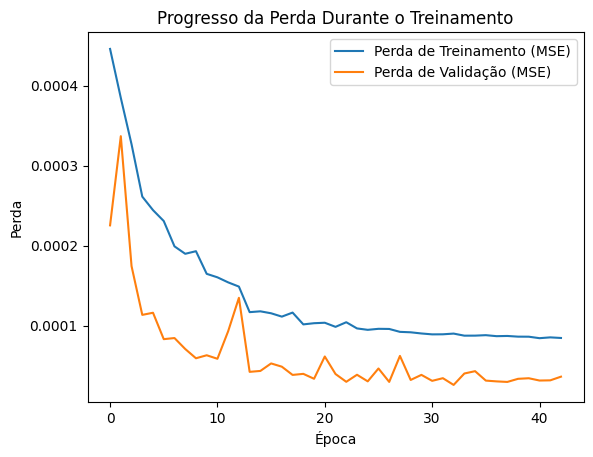

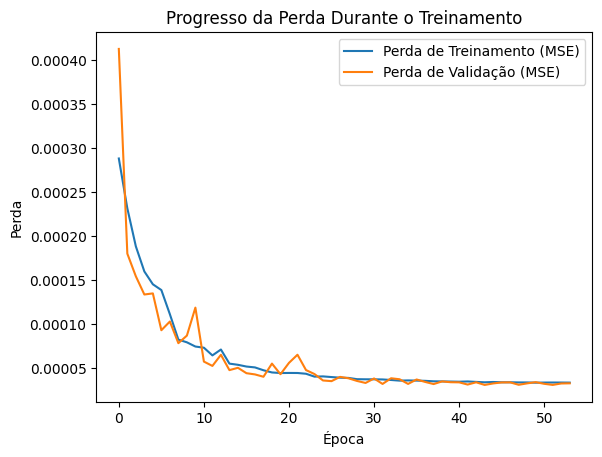

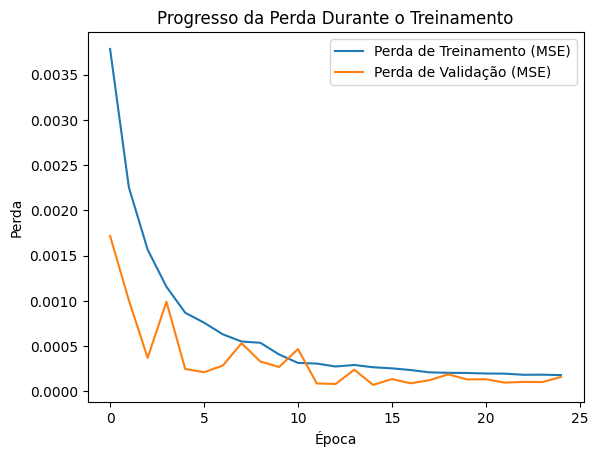

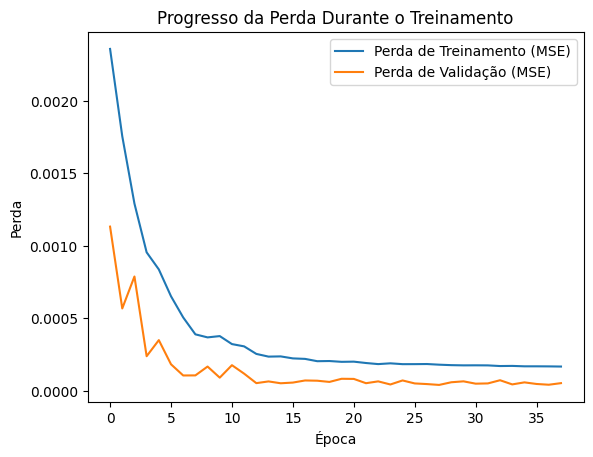

In [8]:
for model_name, data in model_data.items():
    history = data["history"]
    plt.plot(history.history['loss'][5:], label='Perda de Treinamento (MSE)')
    plt.plot(history.history['val_loss'][5:], label='Perda de Validação (MSE)') #pula o primeiro pois a tcn tem perda alta na primeira época
    plt.xlabel('Época')
    plt.ylabel('Perda')
    plt.legend()
    plt.title('Progresso da Perda Durante o Treinamento')
    plt.savefig(f'../images/training_loss_{model_name}.png', dpi=300)
    plt.show()

In [9]:
forecast_df = dataset.copy()

predictions_dict = {}
for model_name, data in model_data.items():
    wrapper = data["wrapper"]
    predictions, actuals = wrapper.rolling_forecast(forecast_df, test_start=val_end)
    predictions_dict[model_name] = {
        "predictions": predictions,
        "actuals": actuals
    }

Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526
Starting rolling forecast from index 7182 to 7526


In [10]:

for model_name, data in predictions_dict.items():
    predictions = data["predictions"]
    actuals = data["actuals"]

    forecast_index = forecast_df.index[val_end + output_steps : val_end + output_steps - 1 + len(actuals)]
    predictions = predictions.reshape(-1)[1:]
    actuals = actuals.reshape(-1)

                            expected  predicted_S2SLSTMBidirectionalWrapper  \
id                                                                            
2021-11-06 05:29:59.999997  7.049589                               7.076120   
2021-11-06 05:40:00.000001  6.976737                               7.006280   
2021-11-06 05:49:59.999996  6.912985                               6.943928   
2021-11-06 06:00:00.000000  6.870333                               6.903651   
2021-11-06 06:10:00.000004  6.812312                               6.847905   

                            predicted_S2SLSTMWrapper  \
id                                                     
2021-11-06 05:29:59.999997                  7.064924   
2021-11-06 05:40:00.000001                  6.994045   
2021-11-06 05:49:59.999996                  6.931732   
2021-11-06 06:00:00.000000                  6.890631   
2021-11-06 06:10:00.000004                  6.834563   

                            predicted_S2STCNBidirecti

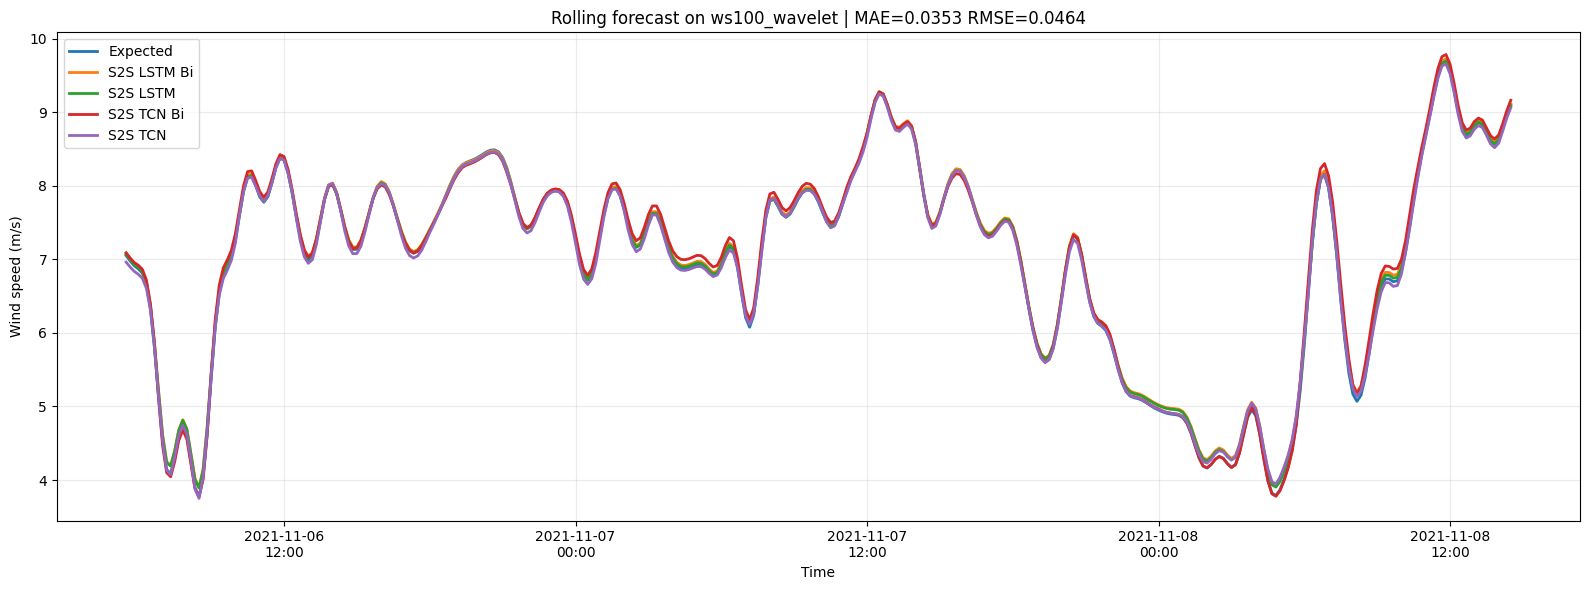

In [11]:
#print(f"Predictions shape: {predictions.shape}")
#old_predictions_df = pd.read_csv(project_root / "data" / "old_prediction.csv")
#old_predictions = old_predictions_df['predictions'].values
#old_predictions = old_predictions.reshape(-1)
#print(f"Old predictions shape: {old_predictions_df.shape}")
#print(old_predictions_df.head())
#print(predictions.head())


mae = mean_absolute_error(actuals[:-1], predictions)
rmse = np.sqrt(mean_squared_error(actuals[:-1], predictions))

results_dict = {
    "expected": actuals[:-1],
}
for model_name, data in predictions_dict.items():
    results_dict[f"predicted_{model_name}"] = data["predictions"].reshape(-1)[1:]
results = pd.DataFrame(
    results_dict,
    index=forecast_index,
)
pretty_name = {
    "expected": "Expected",
    "predicted_S2SLSTMBidirectionalWrapper": "S2S LSTM Bi",
    "predicted_S2SLSTMWrapper": "S2S LSTM",
    "predicted_S2STCNBidirectionalWrapper": "S2S TCN Bi",
    "predicted_S2STCNWrapper": "S2S TCN",
}
print(results.head())

fig, ax = plt.subplots(figsize=(16, 6))
for result in results_dict:
    ax.plot(forecast_index, results[result], label=pretty_name.get(result, result), linewidth=2)
ax.set_title(f"Rolling forecast on ws100_wavelet | MAE={mae:.4f} RMSE={rmse:.4f}")
ax.set_xlabel("Time")
ax.set_ylabel("Wind speed (m/s)")
ax.grid(alpha=0.25)
ax.legend()
ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=8))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d\n%H:%M"))
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
plt.tight_layout()
plt.show()

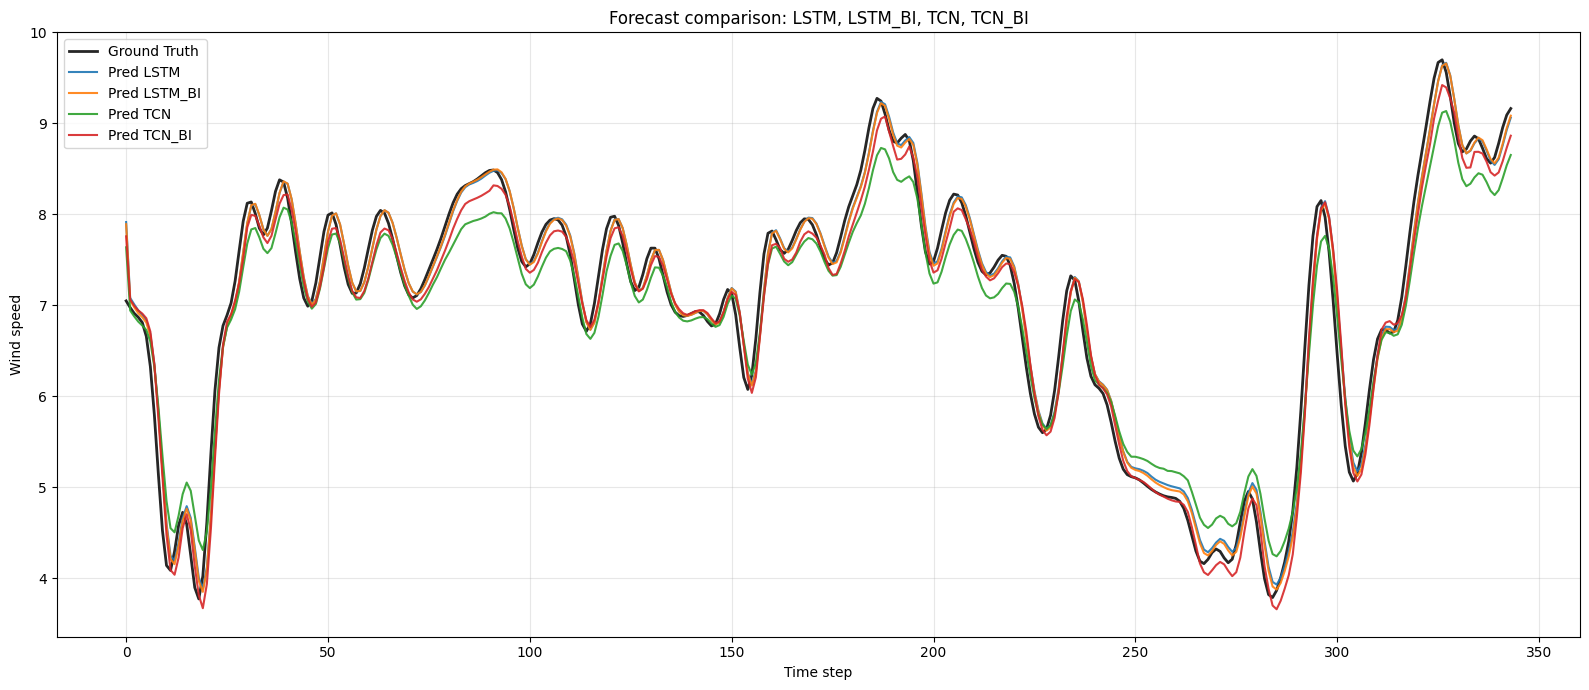

In [12]:
# Added: load predictions from all models and plot in one combined chart
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().resolve()
if not (project_root / "data" / "results").exists():
    project_root = project_root.parent

model_files = {
    "LSTM": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM" / "predictions.csv",
    "LSTM_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_LSTM_Bidirectional" / "predictions.csv",
    "TCN": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN" / "predictions.csv",
    "TCN_BI": project_root / "data" / "results" / "wfo_optuna" / "Seq2Seq_TCN_Bidirectional" / "predictions.csv",
}

results = {}
for model_name, file_path in model_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing predictions file for {model_name}: {file_path}")
    df = pd.read_csv(file_path)
    if "prediction" not in df.columns or "actual" not in df.columns:
        raise ValueError(f"{file_path} must contain columns: prediction, actual")
    results[model_name] = df[["actual", "prediction"]].reset_index(drop=True)

min_len = min(len(df) for df in results.values())
for model_name in results:
    results[model_name] = results[model_name].iloc[:min_len]

actual = results["LSTM"]["actual"].to_numpy()

plt.figure(figsize=(16, 7))
plt.plot(actual, label="Ground Truth", color="black", linewidth=2, alpha=0.85)
for model_name, df in results.items():
    plt.plot(df["prediction"].to_numpy(), label=f"Pred {model_name}", alpha=0.9)

plt.title("Forecast comparison: LSTM, LSTM_BI, TCN, TCN_BI")
plt.xlabel("Time step")
plt.ylabel("Wind speed")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
